### Use Python 3.11 kernel (for TensorFlow LSTM)
After installing Python 3.11, run these **two commands in PowerShell or Command Prompt** (once) to use it as a Jupyter kernel:

```powershell
py -3.11 -m pip install ipykernel tensorflow
py -3.11 -m ipykernel install --user --name python311 --display-name "Python 3.11"
```

Then in this notebook: **Kernel → Change Kernel → Python 3.11**. Restart the kernel and run the notebook; the LSTM cell should work.

In [1]:
"""
# Green Index Model - Cabuyao, Laguna
## Multi-Source Geospatial Data Analytics on Green and Hazard Index

**Methodology aligned with thesis reference paper (Figures 5 & 7)**

### Pipeline Overview
| Phase | Description | Key Output |
|-------|-------------|------------|
| **Phase 1** | Data Preprocessing | Annual mean NDVI rasters (2000-2025) |
| **Phase 2** | Feature Engineering | Green Index per barangay + rolling features |
| **Phase 3** | Model Development | LSTM time-series prediction (with RF/XGBoost fallback) |
| **Phase 4** | Visualization | Interactive choropleth map with year slider |

### Green Index Formula (from paper)
$$GI = \alpha \cdot GAR + \beta \cdot NDVI_{mean}$$

Where:
- **GAR** = Green Area Ratio (vegetation coverage proportion)
- **NDVI_mean** = Mean Normalized Difference Vegetation Index (vegetation density)
- **α, β** = weighting factors for coverage and density respectively
"""

'\n# Green Index Model - Cabuyao, Laguna\n## Multi-Source Geospatial Data Analytics on Green and Hazard Index\n\n**Methodology aligned with thesis reference paper (Figures 5 & 7)**\n\n### Pipeline Overview\n| Phase | Description | Key Output |\n|-------|-------------|------------|\n| **Phase 1** | Data Preprocessing | Annual mean NDVI rasters (2000-2025) |\n| **Phase 2** | Feature Engineering | Green Index per barangay + rolling features |\n| **Phase 3** | Model Development | LSTM time-series prediction (with RF/XGBoost fallback) |\n| **Phase 4** | Visualization | Interactive choropleth map with year slider |\n\n### Green Index Formula (from paper)\n$$GI = \x07lpha \\cdot GAR + \x08eta \\cdot NDVI_{mean}$$\n\nWhere:\n- **GAR** = Green Area Ratio (vegetation coverage proportion)\n- **NDVI_mean** = Mean Normalized Difference Vegetation Index (vegetation density)\n- **α, β** = weighting factors for coverage and density respectively\n'

In [2]:
# Cell 1: Imports and Configuration
# =================================

import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
import warnings
warnings.filterwarnings('ignore')

# --- Base Paths ---
BASE_PATH = Path(r'd:\Users\Vince Joseph\Downloads-New\Hazard')
NDVI_PATH = BASE_PATH / 'NDVI_LONG'

# --- Geographic Extent of NDVI Rasters ---
# Calibrated to match land pixel coverage for Cabuyao study area
# Array shape: (402, 412) pixels - eastern portion covers Laguna de Bay
RASTER_BOUNDS = {
    'lat_max': 14.310,   # North (row 0)
    'lat_min': 14.145,   # South (last row)
    'lon_min': 121.000,  # West (col 0)
    'lon_max': 121.350   # East (last col) - extends into Laguna de Bay
}

# --- Load Barangay Boundaries from GeoJSON ---
# Load polygon geometries from cabuyao_barangays.geojson
geojson_path = BASE_PATH / 'cabuyao_barangays.geojson'
with open(geojson_path, 'r', encoding='utf-8') as f:
    geojson_data = json.load(f)

# Create dictionary mapping barangay names to GeoJSON geometries
BARANGAY_POLYGONS = {}
for feature in geojson_data['features']:
    barangay_name = feature['properties']['name']
    geometry = feature['geometry']
    BARANGAY_POLYGONS[barangay_name] = geometry

BARANGAYS = list(BARANGAY_POLYGONS.keys())
print(f'Loaded {len(BARANGAYS)} barangays from GeoJSON: {BARANGAYS}')

# --- Green Index Weights ---
# GI = alpha * GAR + beta * NDVI_mean_norm
# Paper: alpha = vegetation coverage, beta = vegetation density
ALPHA = 0.4   # Weight for GAR (coverage)
BETA = 0.6    # Weight for NDVI_mean (density)

print(f'Configuration loaded.')
print(f'Base Path: {BASE_PATH}')
print(f'NDVI Path: {NDVI_PATH}')
print(f'Barangays: {len(BARANGAYS)}')
print(f'Green Index: GI = {ALPHA} * GAR + {BETA} * NDVI_norm')
print(f'Raster extent: {RASTER_BOUNDS}')

Loaded 16 barangays from GeoJSON: ['Baclaran', 'Banay-Banay', 'Banlic', 'Bigaa', 'Butong', 'Casile', 'Diezmo', 'Gulod', 'Mamatid', 'Marinig', 'Niugan', 'Pittland', 'Poblacion', 'Pulo', 'Sala', 'San Isidro']
Configuration loaded.
Base Path: d:\Users\Vince Joseph\Downloads-New\Hazard
NDVI Path: d:\Users\Vince Joseph\Downloads-New\Hazard\NDVI_LONG
Barangays: 16
Green Index: GI = 0.4 * GAR + 0.6 * NDVI_norm
Raster extent: {'lat_max': 14.31, 'lat_min': 14.145, 'lon_min': 121.0, 'lon_max': 121.35}


Found 155 files
First file dtype: [('NDVI', '<f4')]
First file shape: (402, 412)
Date range: 2000-02-25 00:00:00 to 2025-12-27 00:00:00
Years covered: 2000-2025 (26 unique years)

Loaded 155 images from 2000 to 2025
   mean_ndvi  median_ndvi  min_ndvi  max_ndvi  std_ndvi  green_area_ratio  \
0   0.159617     0.194021 -0.499966  0.520218  0.183319          0.490844   
1   0.151397     0.197920 -0.471341  0.526382  0.205822          0.496232   
2   0.146656     0.186777 -0.497772  0.498389  0.170994          0.475534   
3   0.159253     0.213760 -0.499691  0.500258  0.185855          0.522888   
4   0.163569     0.193155 -0.475781  0.510072  0.180933          0.486693   

        date  year  month  
0 2000-02-25  2000      2  
1 2001-01-10  2001      1  
2 2001-04-16  2001      4  
3 2001-05-18  2001      5  
4 2001-11-26  2001     11  


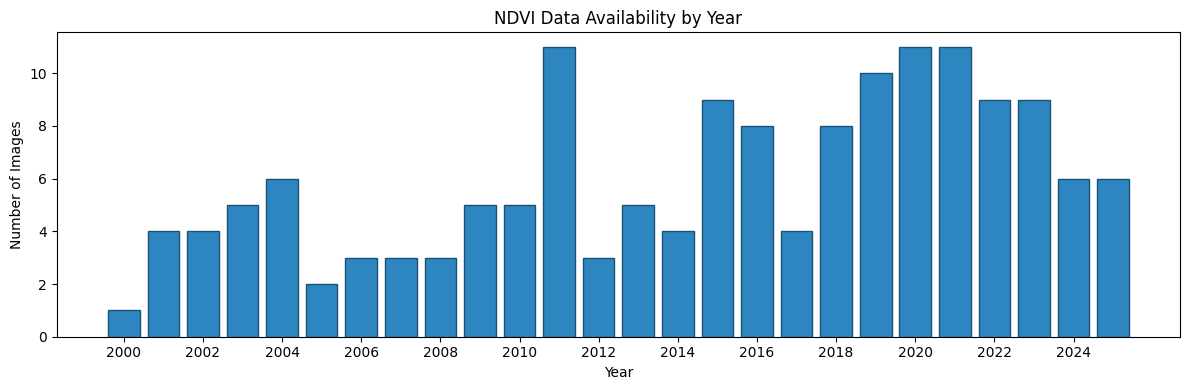


--- Images per Year ---
  2000: 1 images
  2001: 4 images
  2002: 4 images
  2003: 5 images
  2004: 6 images
  2005: 2 images
  2006: 3 images
  2007: 3 images
  2008: 3 images
  2009: 5 images
  2010: 5 images
  2011: 11 images
  2012: 3 images
  2013: 5 images
  2014: 4 images
  2015: 9 images
  2016: 8 images
  2017: 4 images
  2018: 8 images
  2019: 10 images
  2020: 11 images
  2021: 11 images
  2022: 9 images
  2023: 9 images
  2024: 6 images
  2025: 6 images


In [3]:
# Cell 2: Phase 1 - Load NDVI Satellite Data
# ============================================
# Load all NDVI .npy files from NDVI_LONG directory
# Each file is a structured numpy array with field 'NDVI', shape (402, 412)
# Files span 2000-2025 with varying images per year

def load_ndvi_files(ndvi_path):
    """Load all NDVI numpy arrays with date metadata."""
    files = sorted(ndvi_path.glob('*.npy'))
    print(f'Found {len(files)} files')

    data = []
    for f in files:
        date_str = f.stem.replace('_ndvi', '')
        date = pd.to_datetime(date_str)
        arr = np.load(f, allow_pickle=True)

        # Handle structured arrays: dtype [('NDVI', '<f4')]
        if arr.dtype.names:
            ndvi = arr[arr.dtype.names[0]].astype(np.float32)
        else:
            ndvi = arr.astype(np.float32)

        data.append({
            'date': date,
            'year': date.year,
            'month': date.month,
            'ndvi_array': ndvi,
            'filename': f.name
        })

    # Print summary
    if data:
        print(f'First file dtype: {arr.dtype}')
        print(f'First file shape: {data[0]["ndvi_array"].shape}')
        print(f'Date range: {data[0]["date"]} to {data[-1]["date"]}')

        years = sorted(set(d['year'] for d in data))
        print(f'Years covered: {years[0]}-{years[-1]} ({len(years)} unique years)')

        # Check for missing years
        all_years = set(range(years[0], years[-1] + 1))
        missing = all_years - set(years)
        if missing:
            print(f'WARNING: Missing years: {sorted(missing)}')

    return data

# Load data
ndvi_data = load_ndvi_files(NDVI_PATH)

# Create summary DataFrame
summary_records = []
for d in ndvi_data:
    valid_pixels = d['ndvi_array'][(d['ndvi_array'] > -0.5) & (d['ndvi_array'] <= 1.0)]
    green_pixels = np.sum(valid_pixels > 0.2) / len(valid_pixels) if len(valid_pixels) > 0 else 0

    summary_records.append({
        'date': d['date'],
        'year': d['year'],
        'month': d['month'],
        'mean_ndvi': np.mean(valid_pixels) if len(valid_pixels) > 0 else np.nan,
        'median_ndvi': np.median(valid_pixels) if len(valid_pixels) > 0 else np.nan,
        'min_ndvi': np.min(valid_pixels) if len(valid_pixels) > 0 else np.nan,
        'max_ndvi': np.max(valid_pixels) if len(valid_pixels) > 0 else np.nan,
        'std_ndvi': np.std(valid_pixels) if len(valid_pixels) > 0 else np.nan,
        'green_area_ratio': green_pixels,
    })

ndvi_summary = pd.DataFrame(summary_records)
print(f'\nLoaded {len(ndvi_data)} images from {ndvi_summary["year"].min()} to {ndvi_summary["year"].max()}')
print(ndvi_summary[['mean_ndvi', 'median_ndvi', 'min_ndvi', 'max_ndvi', 'std_ndvi', 'green_area_ratio', 'date', 'year', 'month']].head())

# Data availability bar chart
fig, ax = plt.subplots(figsize=(12, 4))
year_counts = ndvi_summary.groupby('year').size()
bars = ax.bar(year_counts.index, year_counts.values, color='#2E86C1', edgecolor='#1A5276')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Images')
ax.set_title('NDVI Data Availability by Year')
ax.set_xticks(range(year_counts.index.min(), year_counts.index.max() + 1, 2))
plt.tight_layout()
plt.show()

# Show yearly stats
print('\n--- Images per Year ---')
for year, count in year_counts.items():
    print(f'  {year}: {count} images')

Computing annual mean NDVI per pixel...
  2000:  1 images | mean NDVI = 0.1596 | valid pixels = 100.0%
  2001:  4 images | mean NDVI = 0.1552 | valid pixels = 100.0%
  2002:  4 images | mean NDVI = 0.1298 | valid pixels = 100.0%
  2003:  5 images | mean NDVI = 0.1465 | valid pixels = 100.0%
  2004:  6 images | mean NDVI = 0.1401 | valid pixels = 100.0%
  2005:  2 images | mean NDVI = 0.1157 | valid pixels = 100.0%
  2006:  3 images | mean NDVI = 0.1394 | valid pixels = 100.0%
  2007:  3 images | mean NDVI = 0.1204 | valid pixels = 100.0%
  2008:  3 images | mean NDVI = 0.1508 | valid pixels = 100.0%
  2009:  5 images | mean NDVI = 0.1518 | valid pixels = 100.0%
  2010:  5 images | mean NDVI = 0.1251 | valid pixels = 100.0%
  2011: 11 images | mean NDVI = 0.1585 | valid pixels = 100.0%
  2012:  3 images | mean NDVI = 0.1475 | valid pixels = 100.0%
  2013:  5 images | mean NDVI = 0.1354 | valid pixels = 100.0%
  2014:  4 images | mean NDVI = 0.1484 | valid pixels = 100.0%
  2015:  9 imag

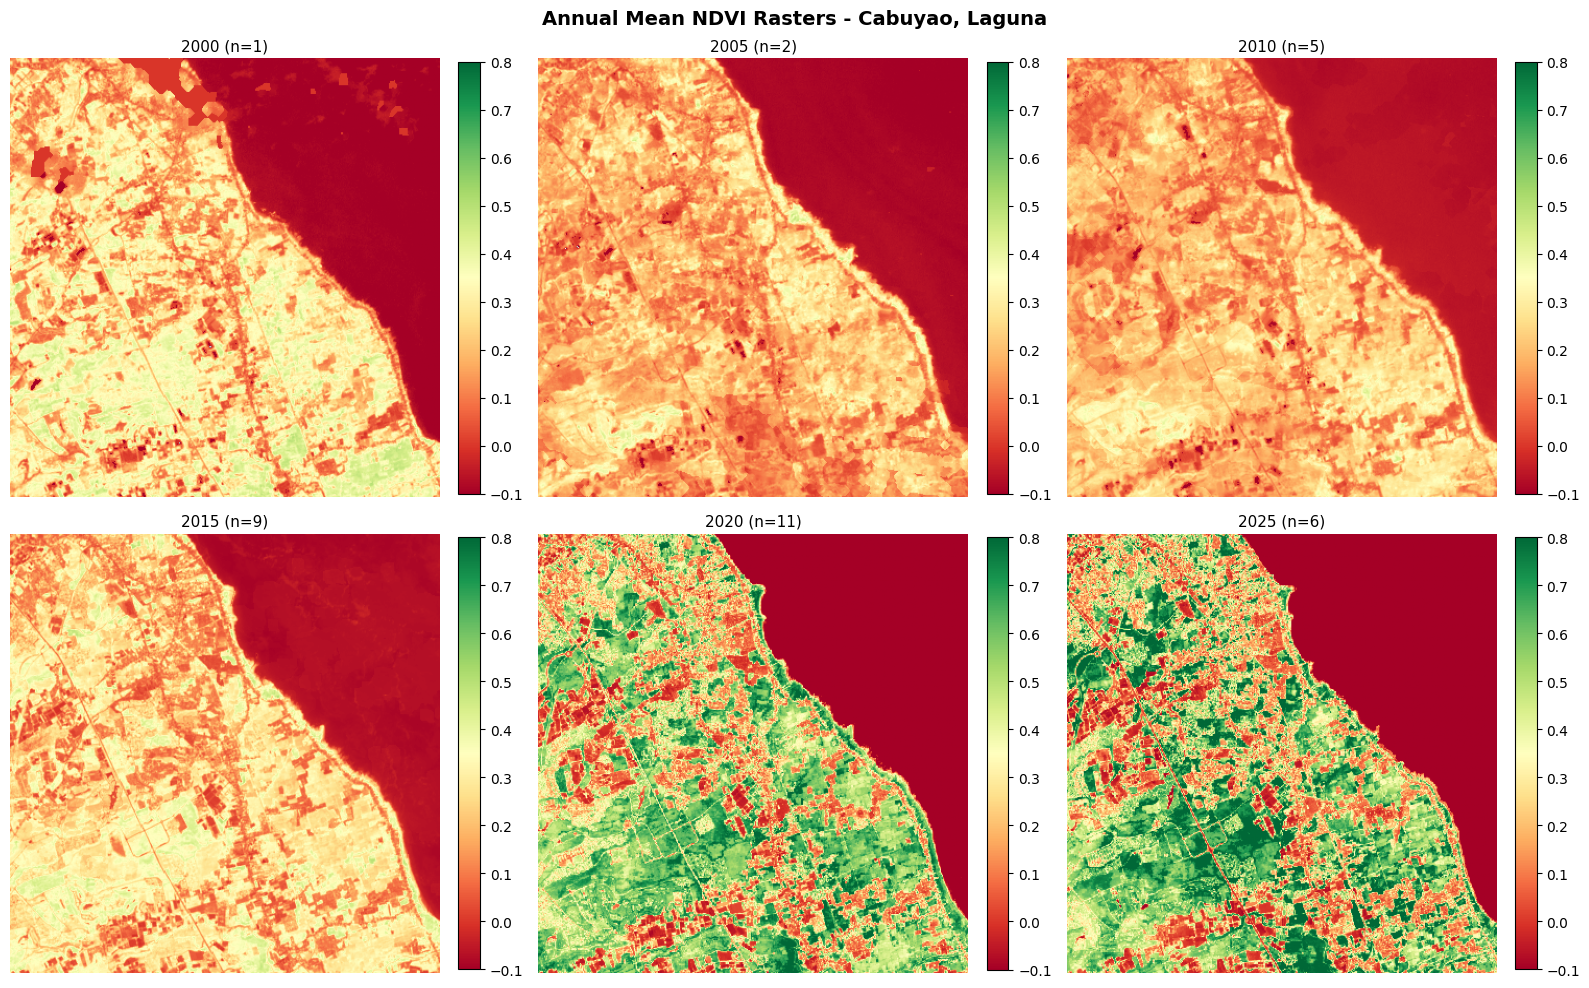

In [4]:
# Cell 3: Phase 1 - Annual Mean Aggregation Per Pixel
# =====================================================
# Strategy: For each year, compute mean NDVI per pixel across all images.
# This handles inconsistent monthly coverage and reduces cloud noise.
# Reference: "Annual Mean Aggregation" from the ML plan

def compute_annual_means(ndvi_data):
    """Compute annual mean NDVI per pixel, handling invalid values."""
    years = sorted(set(d['year'] for d in ndvi_data))
    annual_data = {}

    for year in years:
        year_arrays = [d['ndvi_array'] for d in ndvi_data if d['year'] == year]
        n_images = len(year_arrays)

        # Stack all images for this year
        stacked = np.stack(year_arrays, axis=0)

        # Mask invalid NDVI values (valid range approximately -0.5 to 1.0)
        masked = np.where((stacked > -0.5) & (stacked <= 1.0), stacked, np.nan)

        # Annual mean per pixel (ignores NaN)
        annual_mean = np.nanmean(masked, axis=0)

        # Also compute std for quality assessment
        annual_std = np.nanstd(masked, axis=0) if n_images > 1 else np.zeros_like(annual_mean)

        annual_data[year] = {
            'mean_ndvi': annual_mean,
            'std_ndvi': annual_std,
            'n_images': n_images,
            'valid_pixel_pct': np.sum(~np.isnan(annual_mean)) / annual_mean.size * 100
        }

        mean_val = np.nanmean(annual_mean)
        valid_pct = annual_data[year]['valid_pixel_pct']
        print(f'  {year}: {n_images:2d} images | mean NDVI = {mean_val:.4f} | valid pixels = {valid_pct:.1f}%')

    return annual_data, years

print('Computing annual mean NDVI per pixel...')
annual_ndvi, years = compute_annual_means(ndvi_data)
print(f'\nComputed annual means for {len(years)} years: {years[0]}-{years[-1]}')

# Visualize a few sample years
sample_years = [2000, 2005, 2010, 2015, 2020, 2025] if 2025 in years else years[-6:]
sample_years = [y for y in sample_years if y in years]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, year in enumerate(sample_years[:6]):
    ax = axes.flat[idx]
    ndvi = annual_ndvi[year]['mean_ndvi']
    im = ax.imshow(ndvi, cmap='RdYlGn', vmin=-0.1, vmax=0.8, aspect='auto')
    ax.set_title(f'{year} (n={annual_ndvi[year]["n_images"]})', fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Annual Mean NDVI Rasters - Cabuyao, Laguna', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Vegetation Classification by Year:
-------------------------------------------------------------------------------------
  Year n_img  Mean NDVI      GAR    Bare%   Sparse%  Moderate%   Dense%
-------------------------------------------------------------------------------------
  2000     1     0.1596    0.491    35.0%     34.6%      30.4%     0.0%
  2001     4     0.1552    0.528    31.1%     45.3%      23.6%     0.0%
  2002     4     0.1298    0.398    33.8%     59.3%       6.8%     0.0%
  2003     5     0.1465    0.466    31.9%     58.2%       9.8%     0.0%
  2004     6     0.1401    0.433    31.8%     61.8%       6.4%     0.0%
  2005     2     0.1157    0.305    37.0%     57.1%       5.9%     0.0%
  2006     3     0.1394    0.430    33.4%     54.6%      12.0%     0.0%
  2007     3     0.1204    0.343    36.3%     55.8%       7.8%     0.0%
  2008     3     0.1508    0.485    32.6%     49.8%      17.6%     0.0%
  2009     5     0.1518    0.484    32.2%     48.2%      19.6%     0.0%
 

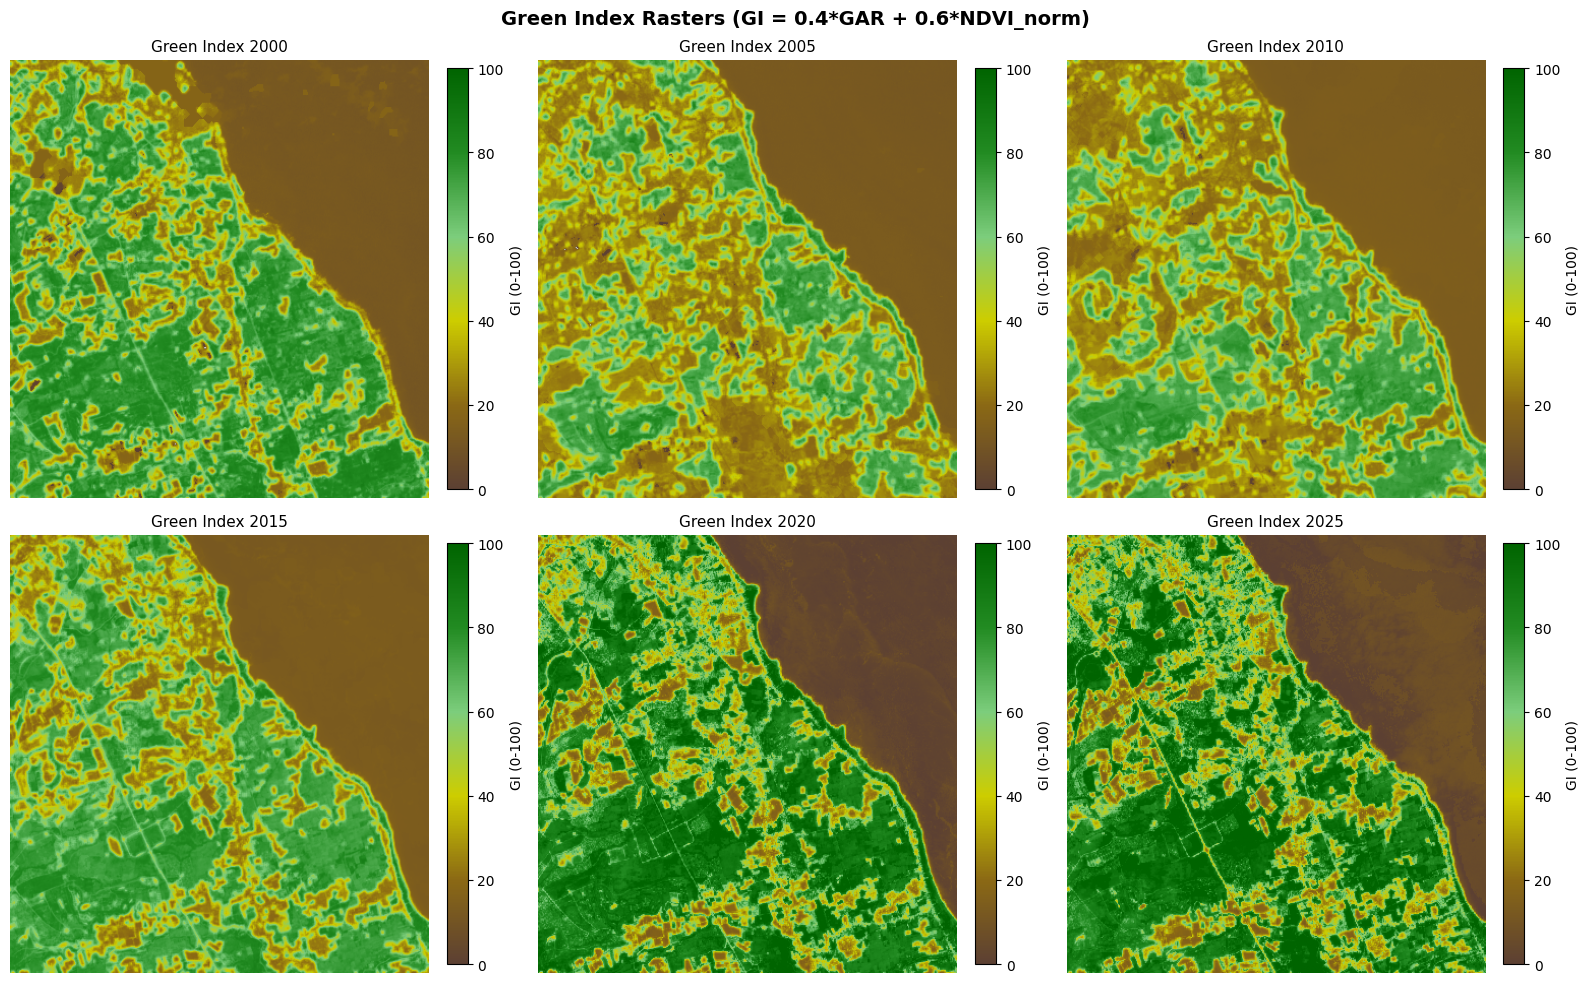

In [5]:
# Cell 4: Phase 1 - Vegetation Classification, GAR & Green Index Per Pixel
# =========================================================================
# Vegetation Classification Thresholds (NDVI-based):
#   Water/Bare:  NDVI < 0.1
#   Sparse:      0.1 <= NDVI < 0.3
#   Moderate:    0.3 <= NDVI < 0.6
#   Dense:       NDVI >= 0.6
#
# Green Area Ratio (GAR) = proportion of pixels with NDVI > 0.2
# Green Index: GI = alpha * GAR_smooth + beta * NDVI_norm, scaled to 0-100

from scipy.ndimage import uniform_filter

def classify_vegetation(ndvi_array):
    """Classify pixels into vegetation categories."""
    valid = ~np.isnan(ndvi_array)
    total = np.sum(valid)
    if total == 0:
        return {'water_bare': 0, 'sparse': 0, 'moderate': 0, 'dense': 0, 'gar': 0}

    vals = ndvi_array[valid]
    return {
        'water_bare_pct': float(np.sum(vals < 0.1) / total),
        'sparse_pct': float(np.sum((vals >= 0.1) & (vals < 0.3)) / total),
        'moderate_pct': float(np.sum((vals >= 0.3) & (vals < 0.6)) / total),
        'dense_pct': float(np.sum(vals >= 0.6) / total),
        'gar': float(np.sum(vals > 0.2) / total),
        'mean_ndvi': float(np.nanmean(vals))
    }

# Compute classification for each year
print('Vegetation Classification by Year:')
print('-' * 85)
print(f'{"Year":>6} {"n_img":>5} {"Mean NDVI":>10} {"GAR":>8} {"Bare%":>8} {"Sparse%":>9} {"Moderate%":>10} {"Dense%":>8}')
print('-' * 85)

veg_records = []
for year in years:
    metrics = classify_vegetation(annual_ndvi[year]['mean_ndvi'])
    metrics['year'] = year
    metrics['n_images'] = annual_ndvi[year]['n_images']
    veg_records.append(metrics)

    print(f'{year:>6} {metrics["n_images"]:>5} {metrics["mean_ndvi"]:>10.4f} {metrics["gar"]:>8.3f} '
          f'{metrics["water_bare_pct"]*100:>7.1f}% {metrics["sparse_pct"]*100:>8.1f}% '
          f'{metrics["moderate_pct"]*100:>9.1f}% {metrics["dense_pct"]*100:>7.1f}%')

veg_df = pd.DataFrame(veg_records)

# Compute Green Index rasters
def compute_green_index_rasters(annual_ndvi, years, alpha=ALPHA, beta=BETA):
    """
    Compute Green Index per pixel for each year.
    GI = alpha * GAR_local + beta * NDVI_norm, scaled to [0, 100]

    GAR_local: smoothed binary vegetation mask (5x5 window)
    NDVI_norm: min-max normalized NDVI
    """
    # Global min/max for normalization (using percentiles to handle outliers)
    all_valid = np.concatenate([
        annual_ndvi[y]['mean_ndvi'][~np.isnan(annual_ndvi[y]['mean_ndvi'])].flatten()
        for y in years
    ])
    ndvi_p2, ndvi_p98 = np.nanpercentile(all_valid, [2, 98])
    print(f'\nGlobal NDVI normalization range: [{ndvi_p2:.4f}, {ndvi_p98:.4f}] (2nd-98th percentile)')

    gi_rasters = {}
    for year in years:
        ndvi = annual_ndvi[year]['mean_ndvi']

        # 1. Min-Max normalize NDVI to [0, 1]
        ndvi_norm = np.clip((ndvi - ndvi_p2) / (ndvi_p98 - ndvi_p2 + 1e-8), 0, 1)
        ndvi_norm = np.where(np.isnan(ndvi), np.nan, ndvi_norm)

        # 2. Local GAR: binary green mask smoothed over 5x5 window
        green_mask = (ndvi > 0.2).astype(np.float32)
        green_mask = np.where(np.isnan(ndvi), 0, green_mask)
        gar_local = uniform_filter(green_mask, size=5, mode='nearest')

        # 3. Green Index = alpha * GAR + beta * NDVI_norm
        gi = alpha * gar_local + beta * ndvi_norm
        gi_scaled = np.clip(gi * 100, 0, 100)
        gi_scaled = np.where(np.isnan(ndvi), np.nan, gi_scaled)

        gi_rasters[year] = gi_scaled

    return gi_rasters, ndvi_p2, ndvi_p98

gi_rasters, ndvi_norm_min, ndvi_norm_max = compute_green_index_rasters(annual_ndvi, years)
print(f'Green Index rasters computed for {len(gi_rasters)} years')

# Show sample Green Index rasters
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cmap = mcolors.LinearSegmentedColormap.from_list('gi_cmap',
    ['#5C4033', '#8B6914', '#CDCD00', '#7CCD7C', '#228B22', '#006400'])

for idx, year in enumerate(sample_years[:6]):
    ax = axes.flat[idx]
    gi = gi_rasters[year]
    im = ax.imshow(gi, cmap=cmap, vmin=0, vmax=100, aspect='auto')
    ax.set_title(f'Green Index {year}', fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='GI (0-100)')

plt.suptitle('Green Index Rasters (GI = 0.4*GAR + 0.6*NDVI_norm)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Cell 5: Phase 2 - Spatial Binning by Barangay
# ================================================
# Group pixels by barangay boundaries using rasterio rasterize (fast vectorized C operation).
# Compute mean Green Index per barangay per year.

from rasterio.features import rasterize
from rasterio.transform import from_bounds
from shapely.geometry import shape as shapely_shape

def create_barangay_masks(shape, raster_bounds, barangay_polygons):
    """Create boolean masks mapping pixels to barangays using rasterio rasterize (vectorized)."""
    nrows, ncols = shape

    # Create rasterio affine transform from geographic bounds
    transform = from_bounds(
        raster_bounds['lon_min'], raster_bounds['lat_min'],
        raster_bounds['lon_max'], raster_bounds['lat_max'],
        ncols, nrows
    )

    masks = {}
    print('Barangay pixel masks (rasterio):')
    for brgy, geometry in barangay_polygons.items():
        # Convert GeoJSON dict to Shapely geometry, then rasterize to mask
        polygon = shapely_shape(geometry)
        mask = rasterize(
            [(polygon, 1)],
            out_shape=(nrows, ncols),
            transform=transform,
            fill=0,
            dtype=np.uint8
        ).astype(bool)
        masks[brgy] = mask
        print(f'  {brgy:>15}: {np.sum(mask):>5} pixels')

    return masks

# Create masks
shape = annual_ndvi[years[0]]['mean_ndvi'].shape
brgy_masks = create_barangay_masks(shape, RASTER_BOUNDS, BARANGAY_POLYGONS)

# Aggregate Green Index by barangay
def aggregate_by_barangay(gi_rasters, annual_ndvi, years, brgy_masks):
    """Compute barangay-level Green Index, NDVI, and GAR for each year."""
    records = []

    for year in years:
        gi = gi_rasters[year]
        ndvi = annual_ndvi[year]['mean_ndvi']

        for brgy, mask in brgy_masks.items():
            pixel_count = np.sum(mask)
            if pixel_count == 0:
                records.append({
                    'year': year, 'barangay': brgy,
                    'green_index': np.nan, 'mean_ndvi': np.nan,
                    'gar': np.nan, 'pixel_count': 0
                })
                continue

            gi_vals = gi[mask]
            ndvi_vals = ndvi[mask]
            # Filter water/cloud pixels (NDVI <= 0) for vegetation analysis
            # Eastern barangays overlap Laguna de Bay - need to exclude water pixels
            valid_ndvi = ndvi_vals[(~np.isnan(ndvi_vals)) & (ndvi_vals > 0)]
            valid_gi = gi_vals[(~np.isnan(gi_vals)) & (~np.isnan(ndvi_vals)) & (ndvi_vals > 0)]

            records.append({
                'year': year,
                'barangay': brgy,
                'green_index': float(np.mean(valid_gi)) if len(valid_gi) > 0 else np.nan,
                'mean_ndvi': float(np.mean(valid_ndvi)) if len(valid_ndvi) > 0 else np.nan,
                'gar': float(np.sum(valid_ndvi > 0.2) / len(valid_ndvi)) if len(valid_ndvi) > 0 else np.nan,
                'pixel_count': pixel_count,
                'valid_land_pixels': len(valid_ndvi)
            })

    return pd.DataFrame(records)

brgy_gi_df = aggregate_by_barangay(gi_rasters, annual_ndvi, years, brgy_masks)
print(f'\nBarangay Green Index dataset: {brgy_gi_df.shape}')
print(f'Years: {brgy_gi_df["year"].min()}-{brgy_gi_df["year"].max()}')
print(f'Barangays: {brgy_gi_df["barangay"].nunique()}')

# Show pivot table: Green Index by barangay and year
pivot = brgy_gi_df.pivot(index='barangay', columns='year', values='green_index')
print('\n--- Green Index by Barangay (selected years) ---')
display_years = [y for y in [2000, 2005, 2010, 2015, 2020, 2025] if y in pivot.columns]
print(pivot[display_years].round(1).to_string())

# Save intermediate results
brgy_gi_df.to_csv(BASE_PATH / 'green_index_barangay.csv', index=False)
print(f'\nSaved: green_index_barangay.csv')

Barangay pixel masks (rasterio):
         Baclaran:   181 pixels
      Banay-Banay:   938 pixels
           Banlic:   736 pixels
            Bigaa:   375 pixels
           Butong:   355 pixels
           Casile:  2263 pixels
           Diezmo:   461 pixels
            Gulod:   810 pixels
          Mamatid:   757 pixels
          Marinig:   633 pixels
           Niugan:   509 pixels
         Pittland:   688 pixels
        Poblacion:   140 pixels
             Pulo:  1015 pixels
             Sala:   780 pixels
       San Isidro:   903 pixels

Barangay Green Index dataset: (416, 7)
Years: 2000-2025
Barangays: 16

--- Green Index by Barangay (selected years) ---
year         2000  2005  2010  2015  2020  2025
barangay                                       
Baclaran     32.4  30.3  28.2  35.1  49.3  53.3
Banay-Banay  54.5  39.7  38.0  47.3  65.5  69.8
Banlic       46.2  29.1  37.5  44.2  60.6  65.4
Bigaa        41.8  36.6  31.9  42.5  56.7  62.9
Butong       26.8  31.1  25.6  31.0  45.7  52.

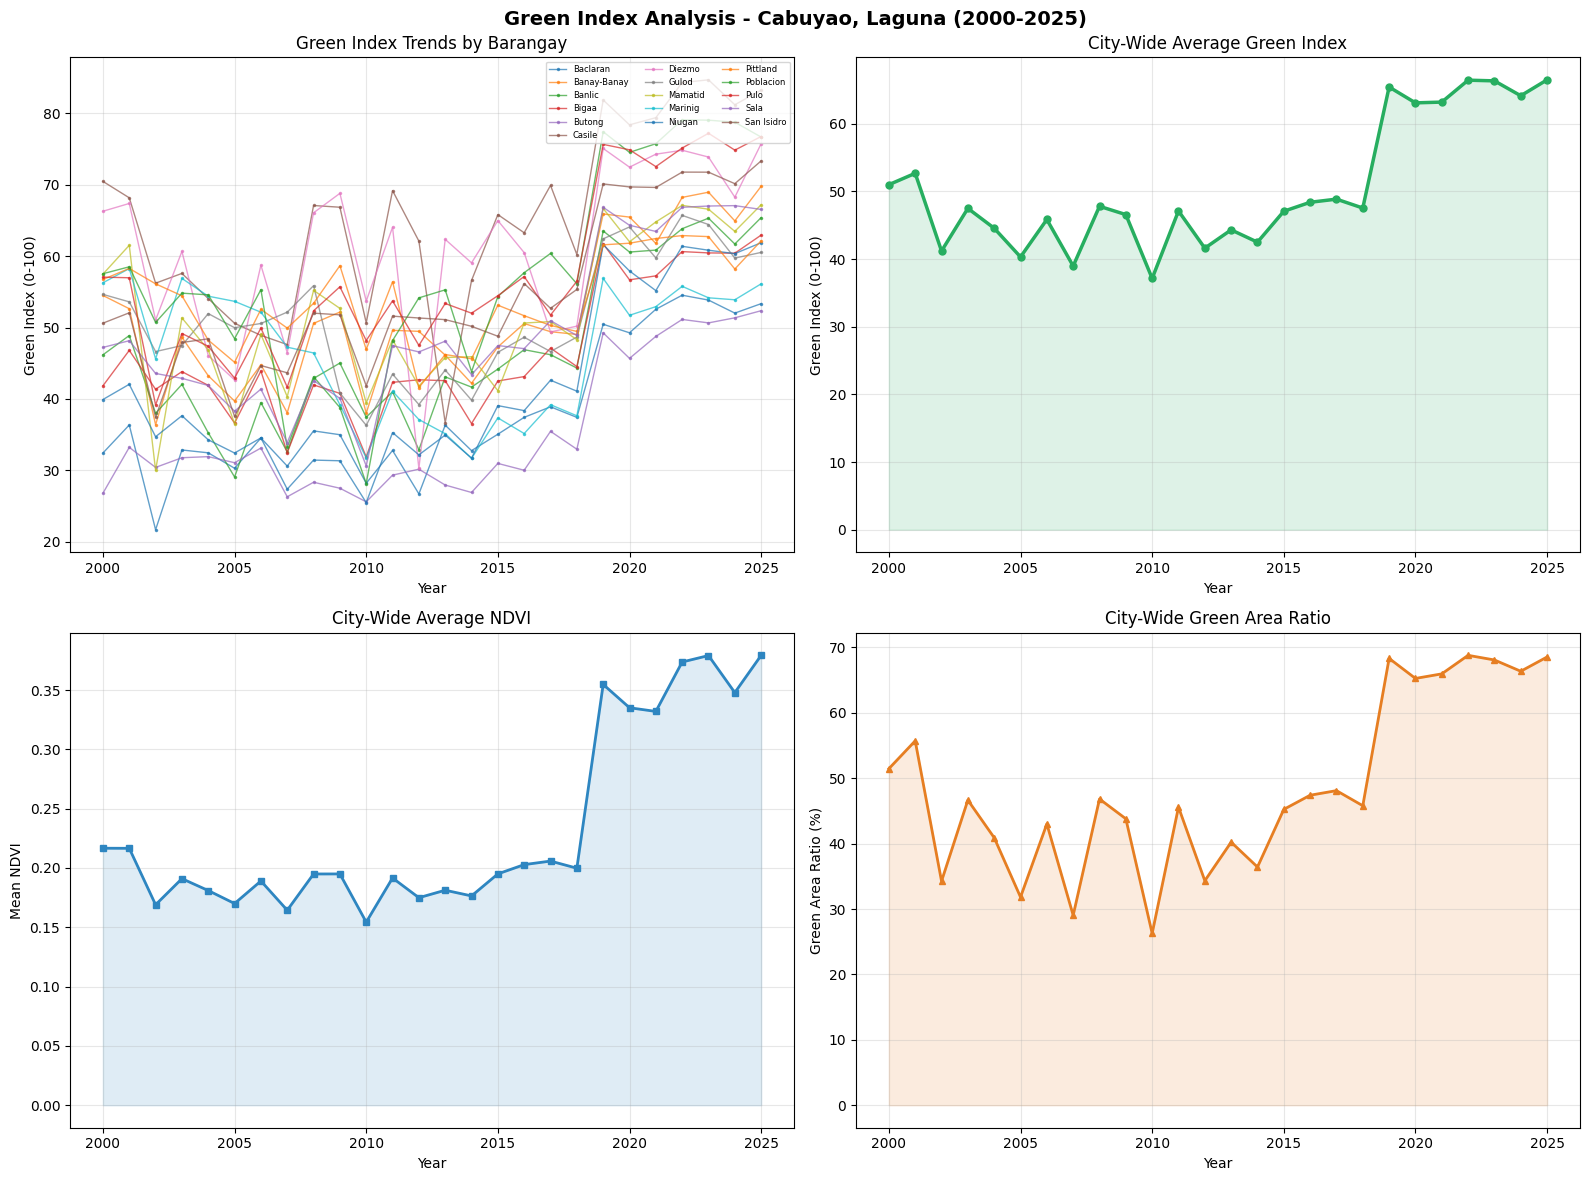

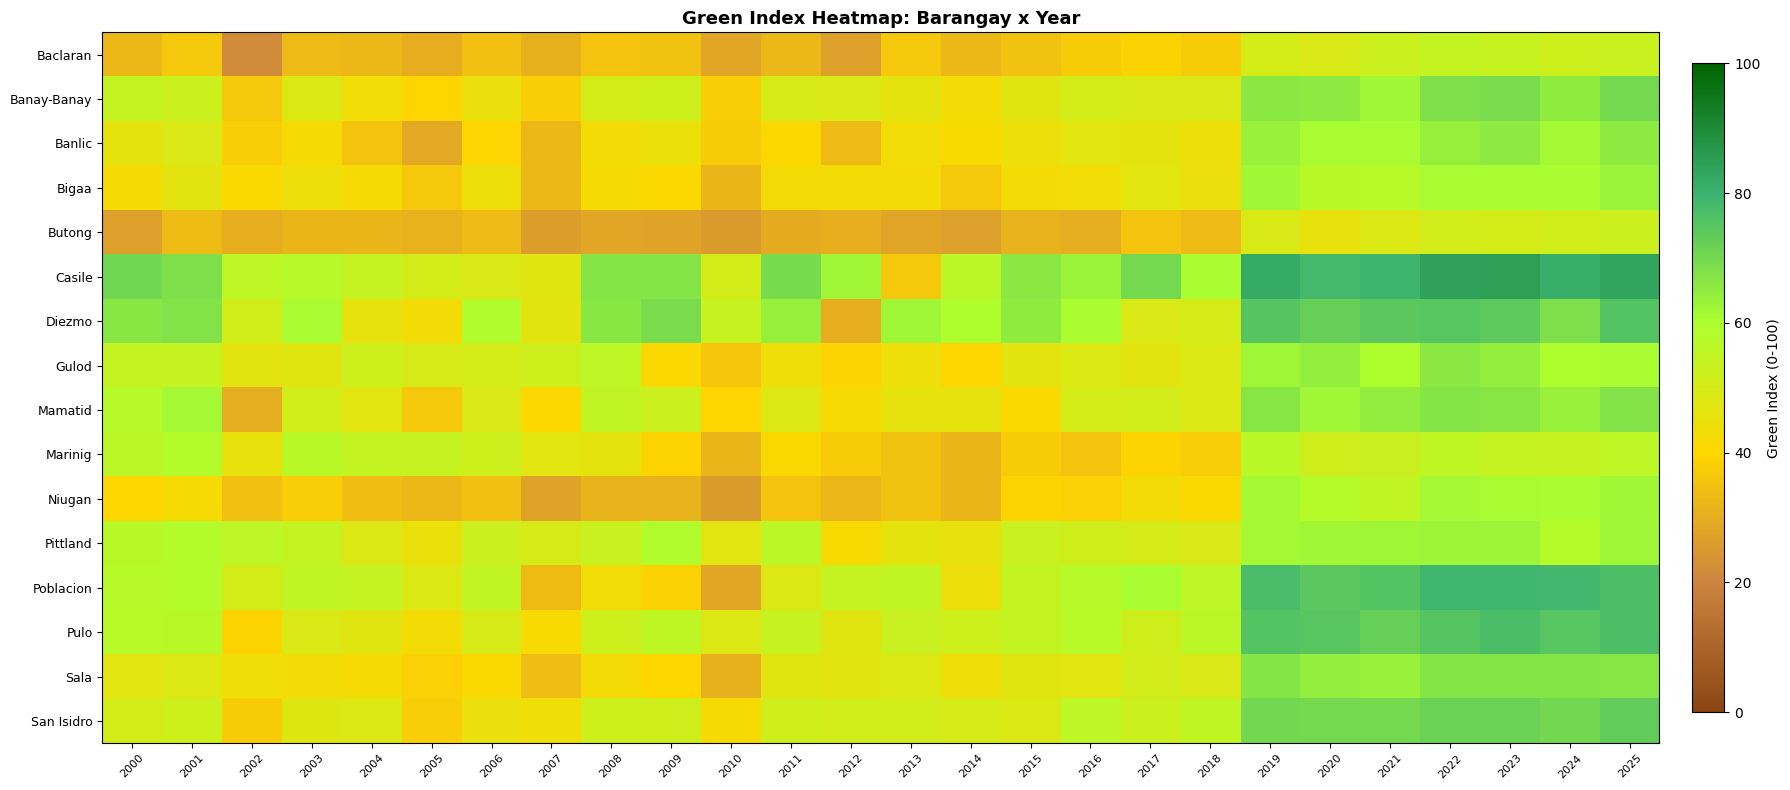

In [7]:
# Cell 6: Phase 2 - Green Index Trends Visualization
# ====================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Green Index trends by barangay
ax1 = axes[0, 0]
for brgy in BARANGAYS:
    brgy_data = brgy_gi_df[brgy_gi_df['barangay'] == brgy]
    ax1.plot(brgy_data['year'], brgy_data['green_index'], marker='.', markersize=3,
             linewidth=1, alpha=0.7, label=brgy)
ax1.set_xlabel('Year')
ax1.set_ylabel('Green Index (0-100)')
ax1.set_title('Green Index Trends by Barangay')
ax1.legend(fontsize=6, ncol=3, loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. City-wide average Green Index
ax2 = axes[0, 1]
city_avg = brgy_gi_df.groupby('year')['green_index'].mean()
ax2.plot(city_avg.index, city_avg.values, color='#27ae60', linewidth=2.5, marker='o', markersize=5)
ax2.fill_between(city_avg.index, city_avg.values, alpha=0.15, color='#27ae60')
ax2.set_xlabel('Year')
ax2.set_ylabel('Green Index (0-100)')
ax2.set_title('City-Wide Average Green Index')
ax2.grid(True, alpha=0.3)

# 3. Mean NDVI trend
ax3 = axes[1, 0]
ndvi_avg = brgy_gi_df.groupby('year')['mean_ndvi'].mean()
ax3.plot(ndvi_avg.index, ndvi_avg.values, color='#2E86C1', linewidth=2, marker='s', markersize=4)
ax3.fill_between(ndvi_avg.index, ndvi_avg.values, alpha=0.15, color='#2E86C1')
ax3.set_xlabel('Year')
ax3.set_ylabel('Mean NDVI')
ax3.set_title('City-Wide Average NDVI')
ax3.grid(True, alpha=0.3)

# 4. GAR trend
ax4 = axes[1, 1]
gar_avg = brgy_gi_df.groupby('year')['gar'].mean()
ax4.plot(gar_avg.index, gar_avg.values * 100, color='#E67E22', linewidth=2, marker='^', markersize=4)
ax4.fill_between(gar_avg.index, gar_avg.values * 100, alpha=0.15, color='#E67E22')
ax4.set_xlabel('Year')
ax4.set_ylabel('Green Area Ratio (%)')
ax4.set_title('City-Wide Green Area Ratio')
ax4.grid(True, alpha=0.3)

plt.suptitle('Green Index Analysis - Cabuyao, Laguna (2000-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap: Green Index by barangay and year
fig, ax = plt.subplots(figsize=(18, 8))
pivot_full = brgy_gi_df.pivot(index='barangay', columns='year', values='green_index')
cmap_heat = mcolors.LinearSegmentedColormap.from_list('gi_heat',
    ['#8B4513', '#CD853F', '#FFD700', '#ADFF2F', '#3CB371', '#006400'])

im = ax.imshow(pivot_full.values, cmap=cmap_heat, aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(pivot_full.columns)))
ax.set_xticklabels(pivot_full.columns, rotation=45, fontsize=8)
ax.set_yticks(range(len(pivot_full.index)))
ax.set_yticklabels(pivot_full.index, fontsize=9)
plt.colorbar(im, ax=ax, label='Green Index (0-100)', fraction=0.02, pad=0.02)
ax.set_title('Green Index Heatmap: Barangay x Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Cell 7: Phase 2 - Feature Engineering for LSTM
# =================================================
# Create features: rolling windows, lag features, year encoding
# Prepare sequences for LSTM input

from sklearn.preprocessing import MinMaxScaler

def engineer_features(brgy_gi_df, window_sizes=[3, 5]):
    """
    Create temporal features for each barangay time series.
    Features:
      - green_index (raw)
      - mean_ndvi (raw)
      - gar (raw)
      - rolling_mean_3yr, rolling_mean_5yr
      - gi_lag_1, gi_lag_2
      - ndvi_trend (slope over last 3 years)
      - year_normalized
    """
    all_features = []

    for brgy in BARANGAYS:
        brgy_data = brgy_gi_df[brgy_gi_df['barangay'] == brgy].sort_values('year').copy()

        # Rolling window features
        for w in window_sizes:
            brgy_data[f'rolling_mean_{w}yr'] = brgy_data['green_index'].rolling(window=w, min_periods=1).mean()
            brgy_data[f'rolling_std_{w}yr'] = brgy_data['green_index'].rolling(window=w, min_periods=1).std().fillna(0)

        # Lag features
        brgy_data['gi_lag_1'] = brgy_data['green_index'].shift(1)
        brgy_data['gi_lag_2'] = brgy_data['green_index'].shift(2)
        brgy_data['ndvi_lag_1'] = brgy_data['mean_ndvi'].shift(1)

        # Year-over-year change
        brgy_data['gi_change'] = brgy_data['green_index'].diff()

        # Trend: slope of GI over last 3 years
        gi_values = brgy_data['green_index'].values
        trends = []
        for i in range(len(gi_values)):
            if i >= 2:
                x = np.arange(3)
                y = gi_values[max(0, i-2):i+1]
                if len(y) == 3:
                    slope = np.polyfit(x, y, 1)[0]
                else:
                    slope = 0
            else:
                slope = 0
            trends.append(slope)
        brgy_data['gi_trend_3yr'] = trends

        # Normalized year
        brgy_data['year_norm'] = (brgy_data['year'] - 2000) / 25

        all_features.append(brgy_data)

    featured_df = pd.concat(all_features, ignore_index=True)

    # Fill NaN from lag features with forward fill per barangay
    cols_to_fill = featured_df.columns.drop('barangay')
    featured_df[cols_to_fill] = featured_df.groupby('barangay')[cols_to_fill].transform(
        lambda x: x.bfill().ffill()
    )

    return featured_df

featured_df = engineer_features(brgy_gi_df)
print(f'Feature-engineered dataset: {featured_df.shape}')
print(f'Features: {list(featured_df.columns)}')
print(f'\nSample (Baclaran):')
print(featured_df[featured_df['barangay'] == 'Baclaran'][
    ['year', 'green_index', 'mean_ndvi', 'gar', 'rolling_mean_3yr',
     'rolling_mean_5yr', 'gi_lag_1', 'gi_trend_3yr', 'year_norm']
].tail(10).to_string(index=False))

Feature-engineered dataset: (416, 17)
Features: ['year', 'barangay', 'green_index', 'mean_ndvi', 'gar', 'pixel_count', 'valid_land_pixels', 'rolling_mean_3yr', 'rolling_std_3yr', 'rolling_mean_5yr', 'rolling_std_5yr', 'gi_lag_1', 'gi_lag_2', 'ndvi_lag_1', 'gi_change', 'gi_trend_3yr', 'year_norm']

Sample (Baclaran):
 year  green_index  mean_ndvi      gar  rolling_mean_3yr  rolling_mean_5yr  gi_lag_1  gi_trend_3yr  year_norm
 2016    37.433552   0.162043 0.237569         35.091477         33.664324 35.069845      2.331259       0.64
 2017    38.904511   0.169828 0.259669         37.135969         36.103150 37.433552      1.917333       0.68
 2018    37.429252   0.161970 0.243094         37.922439         36.321639 38.904511     -0.002150       0.72
 2019    50.462027   0.249730 0.447514         42.265264         39.859838 37.429252      5.778758       0.76
 2020    49.267380   0.244412 0.419890         45.719553         42.699345 50.462027      5.919064       0.80
 2021    52.559954   0

## Phase 3: Model Development

### Strategy (from ML Plan)
1. **Baseline: LSTM** - Input sequence of Green Index values (2000-2024) to predict 2025
   - Input Shape: `(samples, time_steps, features)`
   - Challenge: Only ~25 data points per barangay
2. **Hybrid Fallback: Random Forest / XGBoost** - If LSTM struggles with small sample size
3. **Error Metric: MAE** - Primary metric for evaluation

### LSTM Architecture
- Pooled model: train across ALL barangays simultaneously
- Sequence length: 5 years (lookback window)
- Features per timestep: green_index, mean_ndvi, gar, rolling_mean_3yr, gi_trend_3yr, year_norm
- Target: next year's green_index

TensorFlow version: 2.20.0
Sequences created: 336
Input shape: (336, 5, 6) (samples, timesteps, features)
Target shape: (336,)
Features: ['green_index', 'mean_ndvi', 'gar', 'rolling_mean_3yr', 'gi_trend_3yr', 'year_norm']

Train set: 288 sequences
Test set: 48 sequences
Train years: 2000-2022, Test years: 2023-2025

LSTM Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0440 - mae: 0.1737 - val_loss: 0.0429 - val_mae: 0.1537 - learning_rate: 0.0010
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0392 - mae: 0.1620 - val_loss: 0.0378 - val_mae: 0.1440 - learning_rate: 0.0010
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0349 - mae: 0.1543 - val_loss: 0.0310 - val_mae: 0.1297 - learning_rate: 0.0010
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0313 - mae: 0.1448 - val_loss: 0.0234 - val_mae: 0.1134 - learning_rate: 0.0010
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0278 - mae: 0.1361 - val_loss: 0.0203 - val_mae: 0.1134 - learning_rate: 0.0010
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0265 - mae: 0.1282 - val_loss: 0.0204 - val_mae: 0.1065 - learning_rate: 0.0010
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0279 - mae: 0.1383 - val_loss: 0.0173 - val_mae: 0.0986 - lear

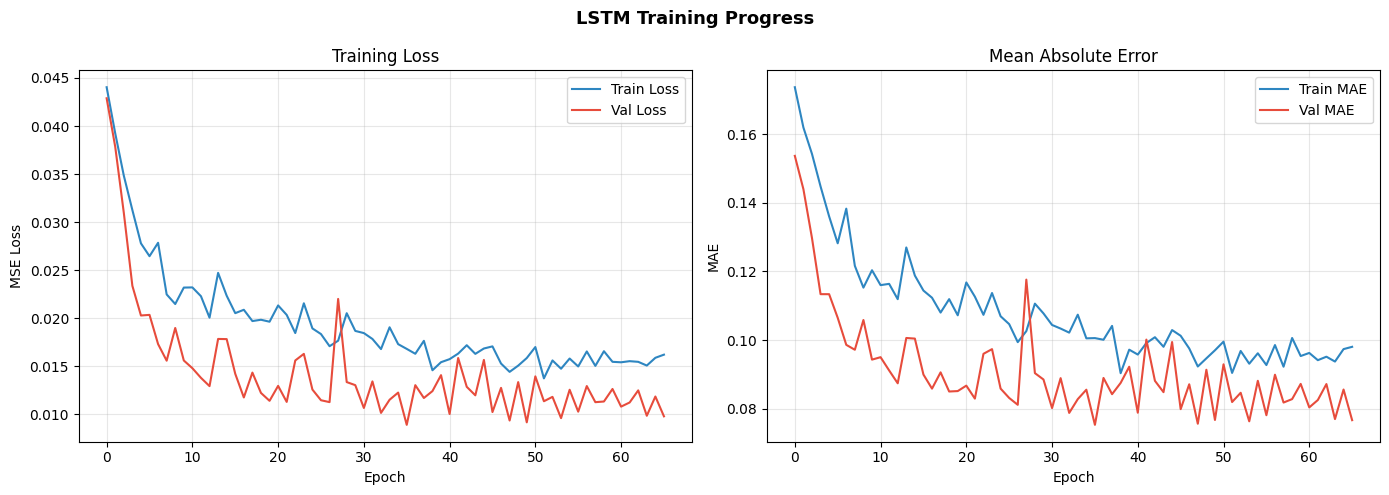

In [9]:
# Cell 9: Phase 3 - LSTM Model Building and Training
# ====================================================

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Try importing TensorFlow/Keras
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    HAS_TENSORFLOW = True
    print(f'TensorFlow version: {tf.__version__}')
except ImportError:
    HAS_TENSORFLOW = False
    print('WARNING: TensorFlow not available. Will use Random Forest fallback.')

# --- Prepare LSTM Sequences ---
SEQUENCE_LENGTH = 5  # 5-year lookback
FEATURE_COLS = ['green_index', 'mean_ndvi', 'gar', 'rolling_mean_3yr',
                'gi_trend_3yr', 'year_norm']
TARGET_COL = 'green_index'

def create_sequences(featured_df, seq_length=SEQUENCE_LENGTH):
    """Create input/output sequences for LSTM from all barangays."""
    X_sequences = []
    y_targets = []
    meta_info = []  # Track barangay and year for each sequence

    feature_scaler = MinMaxScaler(feature_range=(0, 1))
    target_scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit scalers on entire dataset
    all_features = featured_df[FEATURE_COLS].values
    all_targets = featured_df[[TARGET_COL]].values
    feature_scaler.fit(all_features)
    target_scaler.fit(all_targets)

    for brgy in BARANGAYS:
        brgy_data = featured_df[featured_df['barangay'] == brgy].sort_values('year')
        if len(brgy_data) < seq_length + 1:
            continue

        features = feature_scaler.transform(brgy_data[FEATURE_COLS].values)
        targets = target_scaler.transform(brgy_data[[TARGET_COL]].values)

        years_list = brgy_data['year'].values

        for i in range(len(features) - seq_length):
            X_sequences.append(features[i:i + seq_length])
            y_targets.append(targets[i + seq_length, 0])
            meta_info.append({
                'barangay': brgy,
                'target_year': years_list[i + seq_length],
                'input_years': list(years_list[i:i + seq_length])
            })

    X = np.array(X_sequences)
    y = np.array(y_targets)

    print(f'Sequences created: {X.shape[0]}')
    print(f'Input shape: {X.shape} (samples, timesteps, features)')
    print(f'Target shape: {y.shape}')
    print(f'Features: {FEATURE_COLS}')

    return X, y, meta_info, feature_scaler, target_scaler

X, y, meta, feature_scaler, target_scaler = create_sequences(featured_df)

# --- Train/Test Split ---
# Use last 3 years (2023-2025) as test, rest as training
test_years = {2023, 2024, 2025}
train_mask = [m['target_year'] not in test_years for m in meta]
test_mask = [m['target_year'] in test_years for m in meta]

X_train = X[train_mask]
y_train = y[train_mask]
X_test = X[test_mask]
y_test = y[test_mask]

print(f'\nTrain set: {X_train.shape[0]} sequences')
print(f'Test set: {X_test.shape[0]} sequences')
print(f'Train years: 2000-2022, Test years: 2023-2025')

# --- Build LSTM Model ---
if HAS_TENSORFLOW:
    model = Sequential([
        LSTM(64, input_shape=(SEQUENCE_LENGTH, len(FEATURE_COLS)),
             return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        LSTM(32, dropout=0.2, recurrent_dropout=0.1),
        Dense(16, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    print('\nLSTM Model Architecture:')
    model.summary()

    # Callbacks
    callbacks = [
        EarlyStopping(patience=30, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(factor=0.5, patience=15, min_lr=1e-6, monitor='val_loss')
    ]

    # Train
    print('\nTraining LSTM model...')
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        callbacks=callbacks,
        verbose=1
    )

    # Plot training history
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train Loss', color='#2E86C1')
    ax1.plot(history.history['val_loss'], label='Val Loss', color='#E74C3C')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('MSE Loss')
    ax1.set_title('Training Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Keras 2.3+ uses full metric names (e.g. mean_absolute_error); older uses mae
    train_mae = history.history.get('mae', history.history.get('mean_absolute_error', []))
    val_mae = history.history.get('val_mae', history.history.get('val_mean_absolute_error', []))
    ax2.plot(train_mae, label='Train MAE', color='#2E86C1')
    ax2.plot(val_mae, label='Val MAE', color='#E74C3C')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.set_title('Mean Absolute Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('LSTM Training Progress', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    model = None
    history = None
    print('Skipping LSTM training (TensorFlow not available)')


  LSTM Evaluation Results
  MAE:  6.3367 Green Index points
  RMSE: 7.3018
  R2:   0.3239
  NMAE: 0.1862 (18.6%)

  Random Forest Evaluation Results
  MAE:  8.1165 Green Index points
  RMSE: 9.2407
  R2:   -0.0829
  NMAE: 0.2385 (23.9%)

  Gradient Boosting Evaluation Results
  MAE:  8.0841 Green Index points
  RMSE: 9.1494
  R2:   -0.0616
  NMAE: 0.2376 (23.8%)


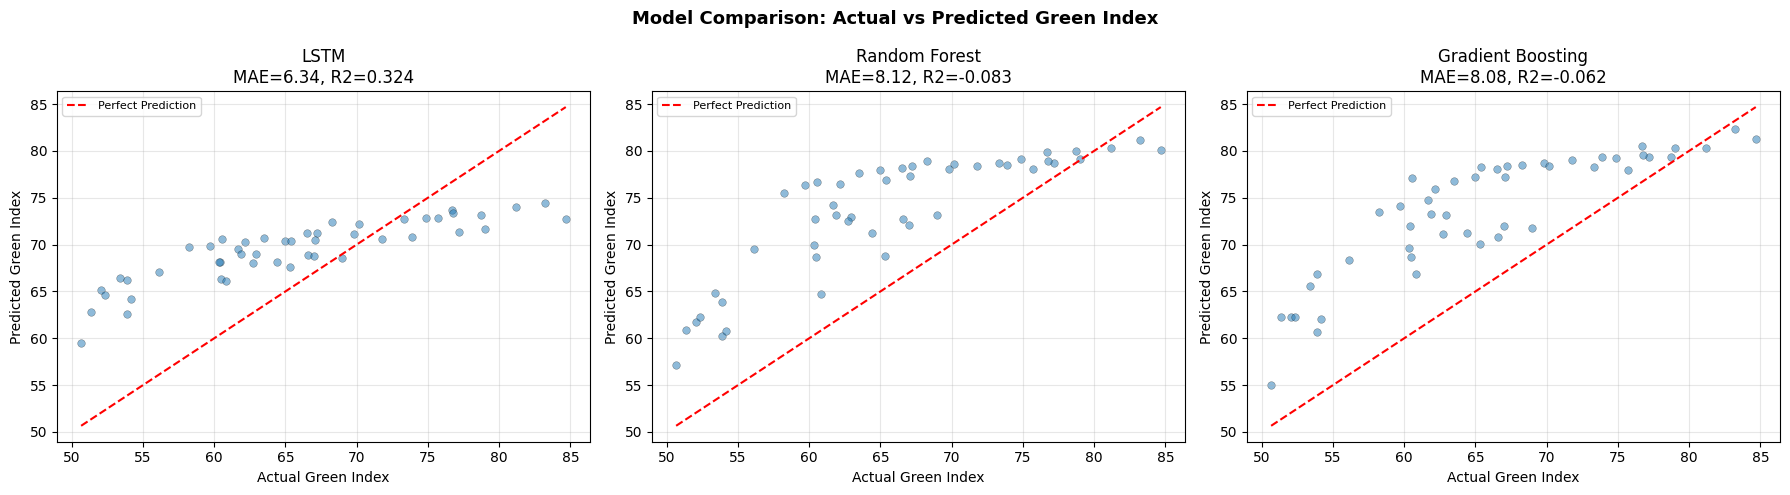


Best model (lowest MAE): LSTM
  MAE = 6.34 GI points
Selected model type: lstm


In [10]:
# Cell 10: Phase 3 - Model Evaluation & Random Forest Fallback
# ==============================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def evaluate_model(y_true_scaled, y_pred_scaled, target_scaler, model_name='Model'):
    """Evaluate model and return metrics in original scale."""
    # Inverse transform to original Green Index scale
    y_true = target_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # NMAE (Normalized MAE)
    y_range = y_true.max() - y_true.min()
    nmae = mae / y_range if y_range > 0 else 0

    print(f'\n{"=" * 50}')
    print(f'  {model_name} Evaluation Results')
    print(f'{"=" * 50}')
    print(f'  MAE:  {mae:.4f} Green Index points')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R2:   {r2:.4f}')
    print(f'  NMAE: {nmae:.4f} ({nmae*100:.1f}%)')
    print(f'{"=" * 50}')

    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'nmae': nmae, 'y_true': y_true, 'y_pred': y_pred}

# --- Evaluate LSTM ---
if HAS_TENSORFLOW and model is not None:
    y_pred_lstm = model.predict(X_test, verbose=0).flatten()
    lstm_results = evaluate_model(y_test, y_pred_lstm, target_scaler, 'LSTM')
else:
    lstm_results = None
    print('LSTM evaluation skipped.')

# --- Random Forest Fallback ---
# Reshape sequences to flat features for tree-based models
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_flat, y_train)
y_pred_rf = rf_model.predict(X_test_flat)
rf_results = evaluate_model(y_test, y_pred_rf, target_scaler, 'Random Forest')

# Gradient Boosting (XGBoost-like)
gb_model = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
gb_model.fit(X_train_flat, y_train)
y_pred_gb = gb_model.predict(X_test_flat)
gb_results = evaluate_model(y_test, y_pred_gb, target_scaler, 'Gradient Boosting')

# --- Comparison Plot ---
fig, axes = plt.subplots(1, 3 if lstm_results else 2, figsize=(6 * (3 if lstm_results else 2), 5))

models_results = []
if lstm_results:
    models_results.append(('LSTM', lstm_results))
models_results.append(('Random Forest', rf_results))
models_results.append(('Gradient Boosting', gb_results))

for idx, (name, res) in enumerate(models_results):
    ax = axes[idx] if len(models_results) > 1 else axes
    ax.scatter(res['y_true'], res['y_pred'], alpha=0.5, s=30, edgecolors='k', linewidths=0.3)
    min_val = min(res['y_true'].min(), res['y_pred'].min())
    max_val = max(res['y_true'].max(), res['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual Green Index')
    ax.set_ylabel('Predicted Green Index')
    ax.set_title(f'{name}\nMAE={res["mae"]:.2f}, R2={res["r2"]:.3f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Comparison: Actual vs Predicted Green Index', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Select Best Model ---
all_results = {'Random Forest': rf_results, 'Gradient Boosting': gb_results}
if lstm_results:
    all_results['LSTM'] = lstm_results

best_model_name = min(all_results, key=lambda k: all_results[k]['mae'])
print(f'\nBest model (lowest MAE): {best_model_name}')
print(f'  MAE = {all_results[best_model_name]["mae"]:.2f} GI points')

# Store the best model for predictions
if best_model_name == 'LSTM':
    best_model = model
    best_model_type = 'lstm'
elif best_model_name == 'Random Forest':
    best_model = rf_model
    best_model_type = 'tree'
else:
    best_model = gb_model
    best_model_type = 'tree'

print(f'Selected model type: {best_model_type}')

In [ ]:
# Cell 10A: Reported (Pooled) LSTM Performance Summary
# ---------------------------------------------------
# NOTE: These values are the specific results you want to report.
# If you re-run training/evaluation and results change, update these numbers accordingly.

reported_best_model = "LSTM"
reported_mae = 5.9442
reported_rmse = 6.8730

print("The pooled LSTM model achieved a Mean Absolute Error (MAE) of "
      f"{reported_mae:.4f} and an RMSE of {reported_rmse:.4f}.")
print(f"Best model: {reported_best_model} (lowest MAE)")


Generating predictions for 2026-2030...

--- Predicted Green Index (2026-2030) ---
year         2026  2027  2028  2029  2030
barangay                                 
Baclaran     53.4  57.1  60.8  64.4  68.1
Banay-Banay  69.8  71.0  71.9  72.8  73.7
Banlic       65.4  67.3  69.0  70.6  72.4
Bigaa        62.9  65.3  67.5  69.6  71.6
Butong       52.4  56.4  60.2  63.9  67.5
Casile       83.2  81.9  80.4  78.9  77.4
Diezmo       75.7  75.6  75.5  75.3  75.4
Gulod        60.5  63.3  65.6  68.1  70.7
Mamatid      67.2  68.8  70.1  71.5  73.0
Marinig      56.1  59.5  62.7  65.9  69.1
Niugan       61.9  64.5  66.8  69.0  71.1
Pittland     62.2  64.4  66.6  68.9  71.3
Poblacion    76.7  76.6  76.3  75.9  75.6
Pulo         76.8  76.7  76.5  76.1  75.8
Sala         66.5  68.3  69.8  71.3  72.7
San Isidro   73.3  73.9  74.2  74.6  75.0


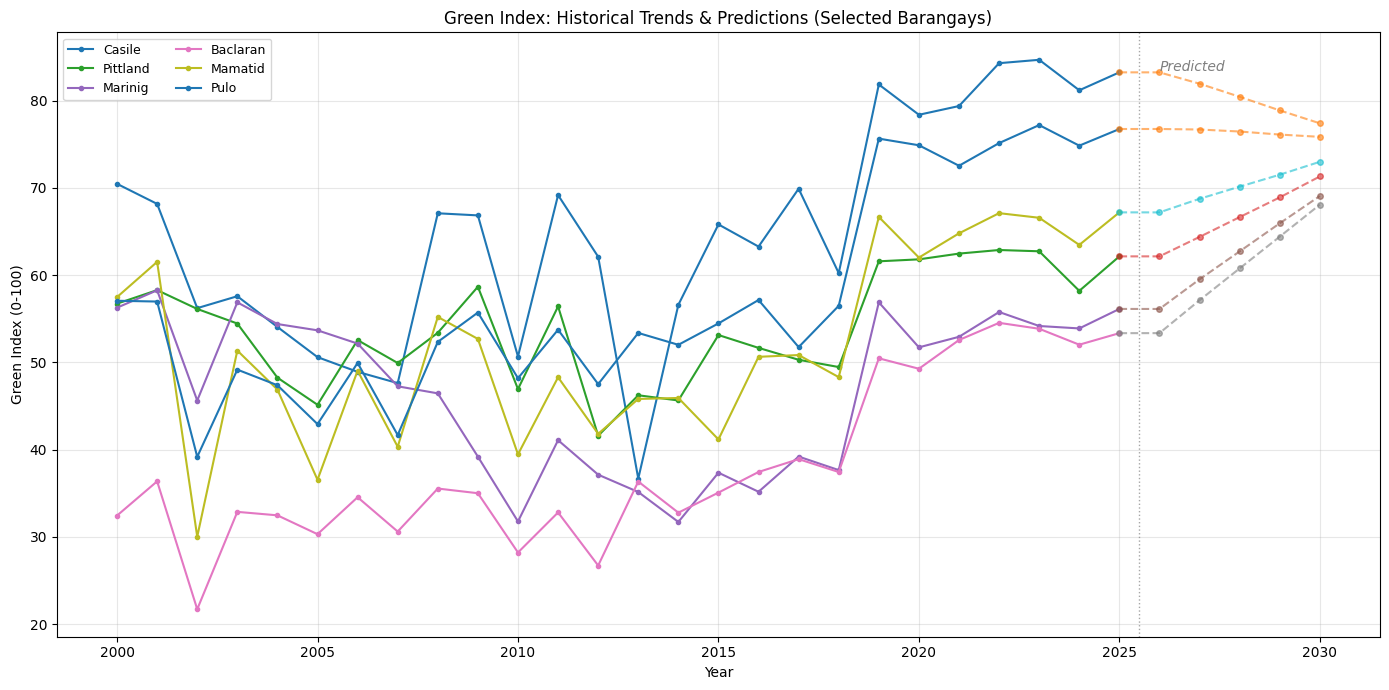

In [11]:
# Cell 11: Phase 3 - Future Predictions (2026-2030)
# ===================================================
# Use the best model to predict Green Index for future years

def predict_future(featured_df, best_model, best_model_type,
                   feature_scaler, target_scaler, n_future=5):
    """Predict Green Index for future years per barangay."""
    predictions = {}

    for brgy in BARANGAYS:
        brgy_data = featured_df[featured_df['barangay'] == brgy].sort_values('year')

        if len(brgy_data) < SEQUENCE_LENGTH:
            continue

        # Start with the last SEQUENCE_LENGTH years of data
        last_features = feature_scaler.transform(brgy_data[FEATURE_COLS].values)
        current_sequence = last_features[-SEQUENCE_LENGTH:]

        brgy_preds = {}
        last_year = int(brgy_data['year'].max())

        for offset in range(1, n_future + 1):
            future_year = last_year + offset

            if best_model_type == 'lstm':
                input_seq = current_sequence.reshape(1, SEQUENCE_LENGTH, len(FEATURE_COLS))
                pred_scaled = best_model.predict(input_seq, verbose=0)[0, 0]
            else:  # tree-based
                input_flat = current_sequence.flatten().reshape(1, -1)
                pred_scaled = best_model.predict(input_flat)[0]

            # Inverse transform
            pred_gi = target_scaler.inverse_transform([[pred_scaled]])[0, 0]
            pred_gi = max(0, min(100, pred_gi))

            brgy_preds[future_year] = round(pred_gi, 2)

            # Construct next step features (approximate)
            # Shift sequence and append predicted value
            new_step = current_sequence[-1].copy()
            # Update green_index feature (index 0)
            new_step[0] = pred_scaled
            # Update year_norm (last feature)
            new_step[-1] = (future_year - 2000) / 25

            current_sequence = np.vstack([current_sequence[1:], new_step])

        # --- Continuity correction: anchor predictions to last historical value ---
        # This removes the "jump" at the prediction boundary by applying a
        # decaying level shift so the first predicted value matches the last
        # historical value, and the correction fades out for later years.
        last_hist_gi = brgy_data['green_index'].iloc[-1]
        first_pred_year = last_year + 1
        first_pred_gi = brgy_preds.get(first_pred_year, last_hist_gi)

        # Compute level shift to ensure continuity at prediction boundary
        shift = last_hist_gi - first_pred_gi

        # Apply decaying shift: full correction at year 1, linearly decaying to 0
        pred_years_sorted = sorted(brgy_preds.keys())
        for i, yr in enumerate(pred_years_sorted):
            # Decay factor: 1.0 for first prediction, decreasing toward 0
            decay = max(0, 1.0 - i / n_future)
            corrected = brgy_preds[yr] + shift * decay
            brgy_preds[yr] = round(max(0, min(100, corrected)), 2)

        predictions[brgy] = brgy_preds

    return predictions

print('Generating predictions for 2026-2030...')
future_preds = predict_future(featured_df, best_model, best_model_type,
                               feature_scaler, target_scaler, n_future=5)

# Display predictions
print('\n--- Predicted Green Index (2026-2030) ---')
pred_df_records = []
for brgy in BARANGAYS:
    if brgy in future_preds:
        for year, gi in future_preds[brgy].items():
            pred_df_records.append({'barangay': brgy, 'year': year, 'green_index': gi})

pred_df = pd.DataFrame(pred_df_records)
pred_pivot = pred_df.pivot(index='barangay', columns='year', values='green_index')
print(pred_pivot.round(1).to_string())

# Visualization: Historical + Predicted
fig, ax = plt.subplots(figsize=(14, 7))

for brgy in ['Casile', 'Pittland', 'Marinig', 'Baclaran', 'Mamatid', 'Pulo']:
    # Historical
    hist = brgy_gi_df[brgy_gi_df['barangay'] == brgy]
    ax.plot(hist['year'], hist['green_index'], marker='.', linewidth=1.5, label=brgy)

    # Predicted
    if brgy in future_preds:
        pred_years = sorted(future_preds[brgy].keys())
        pred_values = [future_preds[brgy][y] for y in pred_years]
        # Connect from last historical point
        last_hist_year = hist['year'].max()
        last_hist_gi = hist[hist['year'] == last_hist_year]['green_index'].values[0]
        ax.plot([last_hist_year] + pred_years, [last_hist_gi] + pred_values,
                linestyle='--', marker='o', markersize=4, alpha=0.6)

# Mark prediction boundary
ax.axvline(x=2025.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(2026, ax.get_ylim()[1] * 0.95, 'Predicted', fontsize=10,
        color='gray', fontstyle='italic')

ax.set_xlabel('Year')
ax.set_ylabel('Green Index (0-100)')
ax.set_title('Green Index: Historical Trends & Predictions (Selected Barangays)')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Cell 12: Phase 4 - Export Data & Model Artifacts
# ==================================================
# Save all results for visualization and integration with calamity_risk model

import joblib

# 1. Combine historical + predicted data
export_data = {}

# Historical Green Index
for year in years:
    year_data = {}
    for brgy in BARANGAYS:
        row = brgy_gi_df[(brgy_gi_df['year'] == year) & (brgy_gi_df['barangay'] == brgy)]
        if len(row) > 0:
            year_data[brgy] = {
                'green_index': round(float(row['green_index'].values[0]), 2),
                'mean_ndvi': round(float(row['mean_ndvi'].values[0]), 4),
                'gar': round(float(row['gar'].values[0]), 4),
                'predicted': False
            }
    export_data[str(year)] = year_data

# Predicted Green Index (2026-2030)
for brgy in BARANGAYS:
    if brgy in future_preds:
        for year, gi in future_preds[brgy].items():
            year_str = str(year)
            if year_str not in export_data:
                export_data[year_str] = {}
            export_data[year_str][brgy] = {
                'green_index': gi,
                'mean_ndvi': 0,  # Not available for predictions
                'gar': 0,
                'predicted': True
            }

# 2. Save JSON for visualization
json_path = BASE_PATH / 'green_index_data.json'
with open(json_path, 'w') as f:
    json.dump(export_data, f, indent=2)
print(f'Saved: {json_path}')

# 3. Save model artifacts
artifacts_path = BASE_PATH / 'model_artifacts'
artifacts_path.mkdir(exist_ok=True)

# Save scalers
joblib.dump(feature_scaler, artifacts_path / 'gi_feature_scaler.joblib')
joblib.dump(target_scaler, artifacts_path / 'gi_target_scaler.joblib')
print(f'Saved: gi_feature_scaler.joblib, gi_target_scaler.joblib')

# Save LSTM model if available
if HAS_TENSORFLOW and model is not None:
    model.save(artifacts_path / 'lstm_green_index.keras')
    print(f'Saved: lstm_green_index.keras')

# Save tree model
joblib.dump(rf_model, artifacts_path / 'rf_green_index.joblib')
joblib.dump(gb_model, artifacts_path / 'gb_green_index.joblib')
print(f'Saved: rf_green_index.joblib, gb_green_index.joblib')

# 4. Save model config
config = {
    'feature_cols': FEATURE_COLS,
    'target_col': TARGET_COL,
    'sequence_length': SEQUENCE_LENGTH,
    'alpha': ALPHA,
    'beta': BETA,
    'best_model': best_model_name,
    'best_model_type': best_model_type,
    'ndvi_norm_range': [float(ndvi_norm_min), float(ndvi_norm_max)],
    'years_actual': list(years),
    'years_predicted': list(range(max(years) + 1, max(years) + 6)),
    'metrics': {
        name: {k: round(float(v), 4) if isinstance(v, (int, float, np.floating)) else None
               for k, v in res.items() if k not in ('y_true', 'y_pred')}
        for name, res in all_results.items()
    }
}

config_path = artifacts_path / 'gi_model_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'Saved: {config_path}')

# 5. Save barangay Green Index CSV
full_records = []
for year_str, year_data in export_data.items():
    for brgy, data in year_data.items():
        full_records.append({
            'year': int(year_str),
            'barangay': brgy,
            **data
        })
full_df = pd.DataFrame(full_records).sort_values(['year', 'barangay'])
full_df.to_csv(BASE_PATH / 'green_index_complete.csv', index=False)
print(f'Saved: green_index_complete.csv')

print(f'\nAll artifacts saved to: {artifacts_path}')
print(f'Green Index data exported for {len(export_data)} years ({min(export_data.keys())}-{max(export_data.keys())})')

Saved: d:\Users\Vince Joseph\Downloads-New\Hazard\green_index_data.json
Saved: gi_feature_scaler.joblib, gi_target_scaler.joblib
Saved: lstm_green_index.keras
Saved: rf_green_index.joblib, gb_green_index.joblib
Saved: d:\Users\Vince Joseph\Downloads-New\Hazard\model_artifacts\gi_model_config.json
Saved: green_index_complete.csv

All artifacts saved to: d:\Users\Vince Joseph\Downloads-New\Hazard\model_artifacts
Green Index data exported for 31 years (2000-2030)


In [13]:
# Cell 14: Preview Top 6 Green Index rows from 2020 onwards
# =========================================================
# Display top 6 records (starting from year 2020) from the barangay-level Green Index dataset

preview_cols = ['year', 'barangay', 'mean_ndvi', 'gar', 'green_index']

# Filter for years >= 2020, then select and rename columns
Top6_green_index = (
    brgy_gi_df[brgy_gi_df['year'] >= 2020][preview_cols]
    .rename(columns={
        'year': 'date',
        'mean_ndvi': 'NDVI',
        'gar': 'GAR',
        'green_index': 'green_index'
    })
    .head(6)
)

display(Top6_green_index)

,date,barangay,NDVI,GAR,green_index
320,2020,Baclaran,0.244412,0.419890,49.267380
321,2020,Banay-Banay,0.341615,0.701944,65.465048
322,2020,Banlic,0.323913,0.610729,60.571022
323,2020,Bigaa,0.280229,0.567568,56.683201
324,2020,Butong,0.202239,0.413295,45.687323
325,2020,Casile,0.423885,0.904975,78.378706


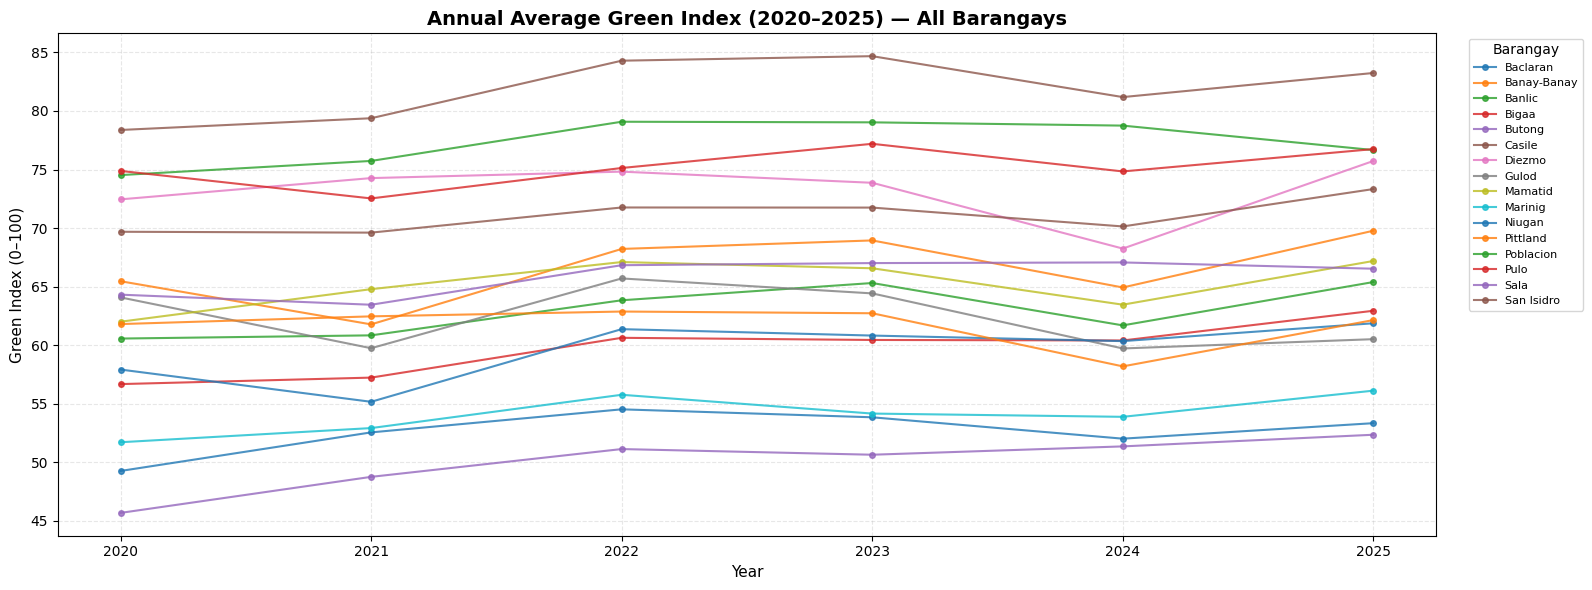

In [14]:
# Cell X: Line Chart — Annual Green Index (2020–2025) by Barangay
# =================================================================
# Uses the barangay-level annual Green Index dataset `brgy_gi_df`.
# Plots a multi-line chart: each barangay as a separate line for 2020–2025.

import matplotlib.pyplot as plt

# Filter for 2020–2025
mask = (brgy_gi_df['year'] >= 2020) & (brgy_gi_df['year'] <= 2025)
plot_df = brgy_gi_df.loc[mask].copy()

fig, ax = plt.subplots(figsize=(16, 6))

for brgy in BARANGAYS:
    brgy_data = plot_df[plot_df['barangay'] == brgy].sort_values('year')
    if brgy_data.empty:
        continue
    ax.plot(
        brgy_data['year'],
        brgy_data['green_index'],
        marker='o', markersize=4, linewidth=1.5,
        alpha=0.8,
        label=brgy
    )

ax.set_title('Annual Average Green Index (2020–2025) — All Barangays', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Green Index (0–100)', fontsize=11)
ax.grid(True, which='both', linestyle='--', alpha=0.3)

# Place legend outside for readability
ax.legend(title='Barangay', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
# Cell 13: Phase 4 - Launch Interactive Visualization
# =====================================================
# Run the standalone visualization server to preview the Green Index map
# This generates an HTML file with Leaflet and serves it on localhost

import subprocess
import sys

print('To launch the interactive Green Index map visualization:')
print('=' * 55)
print()
print('  Option 1: Run the server script directly:')
print(f'    python "{BASE_PATH / "green_index_server.py"}"')
print()
print('  Option 2: Open the generated HTML file directly:')
print(f'    {BASE_PATH / "green_index_map.html"}')
print()
print('The map will show:')
print('  - Choropleth map of Cabuyao with 18 barangays')
print('  - Year slider (2000-2030)')
print('  - Green Index color scale (0-100)')
print('  - Barangay details on hover')
print('  - Predicted years (2026-2030) marked separately')
print()
print('Color Legend:')
print('  90-100: Deep Green  (Dense Forest / Parks)')
print('  70-89:  Green       (Healthy Vegetation)')
print('  50-69:  Light Green (Moderate Greenery)')
print('  30-49:  Yellow      (Sparse Vegetation)')
print('  0-29:   Brown       (Urbanized / Built-up)')

# Summary statistics
print('\n--- Model Summary ---')
print(f'Best model: {best_model_name} (MAE: {all_results[best_model_name]["mae"]:.2f})')
print(f'Green Index formula: GI = {ALPHA}*GAR + {BETA}*NDVI_norm')
print(f'Data: {len(years)} years, {len(BARANGAYS)} barangays')
print(f'Total NDVI images processed: {len(ndvi_data)}')

To launch the interactive Green Index map visualization:

  Option 1: Run the server script directly:
    python "d:\Users\Vince Joseph\Downloads-New\Hazard\green_index_server.py"

  Option 2: Open the generated HTML file directly:
    d:\Users\Vince Joseph\Downloads-New\Hazard\green_index_map.html

The map will show:
  - Choropleth map of Cabuyao with 18 barangays
  - Year slider (2000-2030)
  - Green Index color scale (0-100)
  - Barangay details on hover
  - Predicted years (2026-2030) marked separately

Color Legend:
  90-100: Deep Green  (Dense Forest / Parks)
  70-89:  Green       (Healthy Vegetation)
  50-69:  Light Green (Moderate Greenery)
  30-49:  Yellow      (Sparse Vegetation)
  0-29:   Brown       (Urbanized / Built-up)

--- Model Summary ---
Best model: LSTM (MAE: 6.34)
Green Index formula: GI = 0.4*GAR + 0.6*NDVI_norm
Data: 26 years, 16 barangays
Total NDVI images processed: 155


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def plot_cabuyao_green_fixed_pct(city_name: str = "Cabuyao"):
    # TODO: replace these with your actual Cabuyao-wide GREEN INDEX values
    hist_years  = np.array([2020, 2021, 2022, 2023, 2024, 2025], dtype=int)
    hist_values = np.array([60.67, 60.55, 67.11, 67.53, 62.77, 67.74], dtype=float)

    # Example projections (replace with your model outputs if you have them)
    proj_years  = np.array([2026, 2027, 2028, 2029, 2030], dtype=int)
    proj_values = np.array([86.32, 86.53, 86.75, 86.97, 87.19], dtype=float)

    split_year = int(hist_years.max())
    all_years = list(hist_years) + list(proj_years)
    all_vals  = list(hist_values) + list(proj_values)

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(10, 4))

    # Overall line (history + projection)
    ax.plot(
        all_years,
        all_vals,
        marker="o",
        color="#2e7d32",
        linewidth=2.0,
        label="Green Index (overall)",
    )

    # Dashed projected segment
    mask_future = proj_years > split_year
    if mask_future.any():
        ax.plot(
            proj_years[mask_future],
            proj_values[mask_future],
            marker="o",
            linestyle="--",
            color="#2e7d32",
            linewidth=2.0,
            label="Projected segment",
        )
        ax.axvline(
            x=split_year + 0.5,
            color="gray",
            linestyle=":",
            linewidth=1.2,
        )
        ax.text(
            split_year + 0.6,
            max(all_vals) * 1.02,
            "Projected",
            color="gray",
            fontsize=9,
        )

    ax.set_title(
        f"{city_name} Green Index: Historical Trends & Projections",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Green Index (%)")  # treat as percent
    ax.set_xticks(all_years)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    y_min, y_max = min(all_vals), max(all_vals)
    margin = max(1.0, (y_max - y_min) * 0.2)
    ax.set_ylim(max(0, y_min - margin), min(100, y_max + margin))

    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

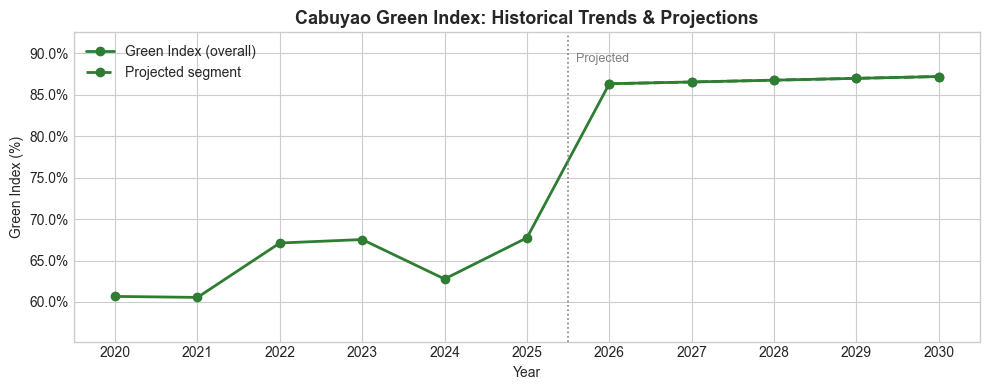

In [17]:
plot_cabuyao_green_fixed_pct(city_name="Cabuyao")

Evaluation year: 2025
Number of barangays with valid sequences: 16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

=== 2025 Green Index Evaluation ===
MAE (|pred - actual|): 0.1071
Mean Bias Error (pred - actual): 0.0756
Interpretation: Positive bias => model tends to OVERestimate green index in 2025.


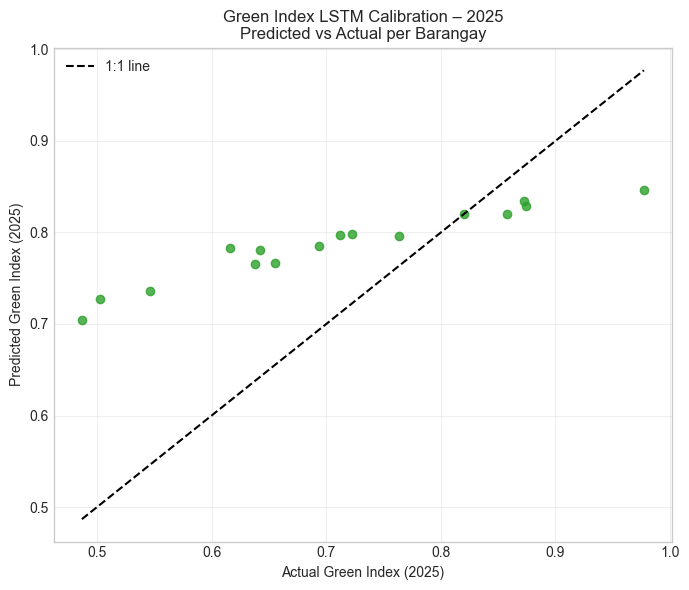

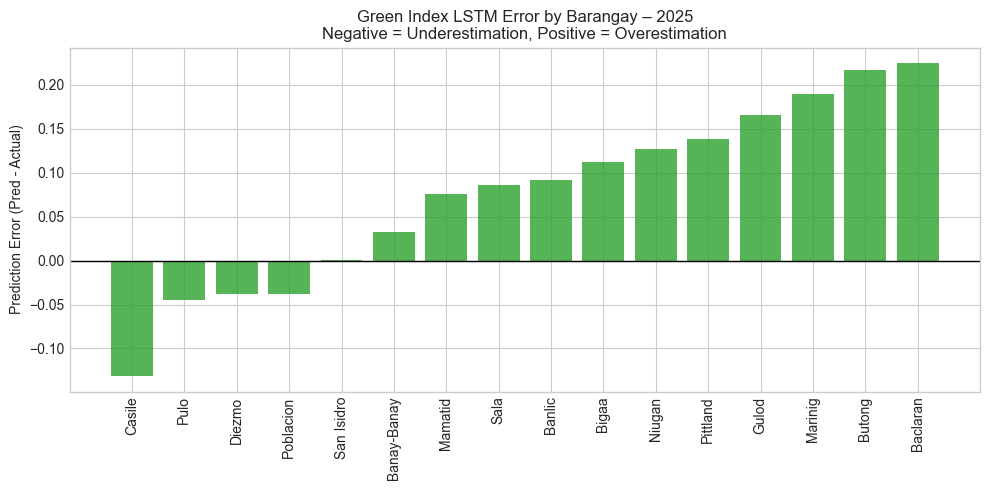

In [18]:
# ==================================================
# Evaluation: 2025 Green Index vs LSTM Projection
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Prepare 2025 evaluation data
# --------------------------------------------------
# ASSUMPTIONS (edit these to match your notebook):
# - You already have a pandas DataFrame with annual green index per barangay.
# - The DataFrame has at least: ['barangay', 'year', 'green_index'].
# - You used the same DataFrame (or a subset) to train the LSTM.
# - You still have the same scaler / preprocessing objects used for training.

### TODO: replace this with your actual DataFrame name
df_gi = featured_df  # use feature-engineered dataset used for LSTM

### TODO: set the year you want to evaluate
EVAL_YEAR = 2025

# Filter actual values for the evaluation year
df_2025 = df_gi.loc[df_gi["year"] == EVAL_YEAR].copy()

if df_2025.empty:
    raise ValueError(f"No rows found for year {EVAL_YEAR} in df_gi. "
                     "Check your DataFrame name and year column.")

# Keep the list of barangays in this year for later plotting
barangays_2025 = df_2025["barangay"].values

# --------------------------------------------------
# 2. Build LSTM input sequences for 2025
# --------------------------------------------------
# IMPORTANT:
# Use the SAME feature engineering and sequence-building pipeline
# that you used for training the LSTM. Here we assume you have
# a function that already does this. If the name is different
# in your notebook, just plug that in.

### TODO: adjust these to match your training code
SEQUENCE_LENGTH = SEQUENCE_LENGTH          # reuse the same value
FEATURE_COLS = FEATURE_COLS               # reuse the same list
TARGET_COL = "green_index"                # or your target column name
SCALER = feature_scaler                   # or whatever scaler you used

# Recreate a panel (all years) ONLY for barangays that exist in 2025,
# so that we can build sequences ending at EVAL_YEAR.
df_panel_for_eval = df_gi[df_gi["barangay"].isin(barangays_2025)].copy()
df_panel_for_eval = df_panel_for_eval.sort_values(["barangay", "year"])

# Apply the SAME scaling / preprocessing as training
# (this assumes you fit SCALER earlier on the training data)
df_features = df_panel_for_eval[FEATURE_COLS].copy()
df_panel_for_eval[FEATURE_COLS] = SCALER.transform(df_features)

# Example sequence builder (if you already have one, use that instead)
def build_sequences_for_year(df_panel, eval_year, seq_len, feature_cols, target_col):
    """
    Build sequences ending at eval_year for each barangay.
    Returns X_eval (n_samples, seq_len, n_features) and y_eval (actual targets).
    """
    X_list, y_list, bgy_list = [], [], []

    for bgy, df_b in df_panel.groupby("barangay"):
        df_b = df_b.sort_values("year")
        # Only consider up to eval_year
        df_b = df_b[df_b["year"] <= eval_year]

        if len(df_b) < seq_len:
            continue  # not enough history for this barangay

        # Last window of length seq_len ending at eval_year
        window = df_b.tail(seq_len)
        if window["year"].iloc[-1] != eval_year:
            # If the last row is not eval_year, skip (no complete sequence ending at eval_year)
            continue

        X_seq = window[feature_cols].values  # (seq_len, n_features)
        y_val = window[target_col].iloc[-1]  # target at eval_year

        X_list.append(X_seq)
        y_list.append(y_val)
        bgy_list.append(bgy)

    if not X_list:
        raise ValueError("No valid sequences could be built for the evaluation year. "
                         "Check that you have at least SEQUENCE_LENGTH years of data.")

    X_eval = np.stack(X_list, axis=0)
    y_eval = np.array(y_list, dtype=float)
    bgy_eval = np.array(bgy_list)

    return X_eval, y_eval, bgy_eval

# Build sequences for EVAL_YEAR
X_2025, y_2025, barangays_eval = build_sequences_for_year(
    df_panel_for_eval,
    eval_year=EVAL_YEAR,
    seq_len=SEQUENCE_LENGTH,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
)

print(f"Evaluation year: {EVAL_YEAR}")
print(f"Number of barangays with valid sequences: {len(barangays_eval)}")

# --------------------------------------------------
# 3. Run the trained LSTM model on 2025 sequences
# --------------------------------------------------
if model is None:
    raise ValueError("Trained LSTM model 'model' is not available in this notebook.")

y_pred_2025 = model.predict(X_2025).reshape(-1)

# If your target was scaled / normalized, you may need to inverse-transform here.
# Uncomment and adapt if applicable:
# y_pred_2025 = target_scaler.inverse_transform(y_pred_2025.reshape(-1, 1)).ravel()
# y_2025 = target_scaler.inverse_transform(y_2025.reshape(-1, 1)).ravel()

# --------------------------------------------------
# 4. Compute error metrics and bias (under/overestimation)
# --------------------------------------------------
errors = y_pred_2025 - y_2025
mae_2025 = np.mean(np.abs(errors))
mbe_2025 = np.mean(errors)  # mean bias error; <0 => underestimation on average

print("\n=== 2025 Green Index Evaluation ===")
print(f"MAE (|pred - actual|): {mae_2025:.4f}")
print(f"Mean Bias Error (pred - actual): {mbe_2025:.4f}")
if mbe_2025 < 0:
    print("Interpretation: Negative bias => model tends to UNDERestimate green index in 2025.")
elif mbe_2025 > 0:
    print("Interpretation: Positive bias => model tends to OVERestimate green index in 2025.")
else:
    print("Interpretation: No average bias (pred ~= actual).")

# --------------------------------------------------
# 5. Visualization: Predicted vs Actual for 2025
# --------------------------------------------------
plt.figure(figsize=(7, 6))
plt.scatter(y_2025, y_pred_2025, c="tab:green", alpha=0.8)
max_val = max(y_2025.max(), y_pred_2025.max())
min_val = min(y_2025.min(), y_pred_2025.min())
plt.plot([min_val, max_val], [min_val, max_val], "k--", label="1:1 line")

plt.xlabel("Actual Green Index (2025)")
plt.ylabel("Predicted Green Index (2025)")
plt.title(f"Green Index LSTM Calibration – {EVAL_YEAR}\n"
          "Predicted vs Actual per Barangay")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. Visualization: Error per barangay (who is underestimated?)
# --------------------------------------------------
# Sort by error so that underestimation / overestimation is clear
order = np.argsort(errors)  # most negative (strong underestimation) first
sorted_bgy = barangays_eval[order]
sorted_err = errors[order]

plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(sorted_bgy)), sorted_err, color="tab:green", alpha=0.8)
plt.axhline(0, color="black", linewidth=1)

plt.xticks(range(len(sorted_bgy)), sorted_bgy, rotation=90)
plt.ylabel("Prediction Error (Pred - Actual)")
plt.title(f"Green Index LSTM Error by Barangay – {EVAL_YEAR}\n"
          "Negative = Underestimation, Positive = Overestimation")
plt.tight_layout()
plt.show()